In [2]:
import tensorflow as tf

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [3]:
# 정답 데이터의 클래스 분포 확인
import numpy as np
np.unique(y_train, return_counts=True), np.unique(y_test, return_counts=True)

((array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
  array([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949])),
 (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
  array([ 980, 1135, 1032, 1010,  982,  892,  958, 1028,  974, 1009])))

In [4]:
# 28*28 => 784 1차원, 정규화(/255.0)
# x_train = x_train.reshape(-1, 28*28) / 255.0
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Dense, Flatten, Input, Rescaling

model = Sequential([
    Input(shape=(28, 28)),  # 입력 (28, 28)
    Rescaling(1./255),      # 정규화
    Flatten(),              # 1차원으로 변환
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# loss = "categorical_crossentropy"         # 원-핫 인코딩된 레이블 사용
# loss = "sparse_categorical_crossentropy"  # 정수 테이블 사용

optimizer = keras.optimizers.Adam(learning_rate=0.001)
loss = keras.losses.SparseCategoricalCrossentropy() # 정수 레이블 사용
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

In [6]:
history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=50, verbose=2)

Epoch 1/50
1875/1875 - 4s - 2ms/step - accuracy: 0.9295 - loss: 0.2431 - val_accuracy: 0.9613 - val_loss: 0.1273
Epoch 2/50
1875/1875 - 3s - 2ms/step - accuracy: 0.9693 - loss: 0.1028 - val_accuracy: 0.9686 - val_loss: 0.1043
Epoch 3/50
1875/1875 - 4s - 2ms/step - accuracy: 0.9775 - loss: 0.0718 - val_accuracy: 0.9710 - val_loss: 0.0945
Epoch 4/50
1875/1875 - 4s - 2ms/step - accuracy: 0.9827 - loss: 0.0544 - val_accuracy: 0.9766 - val_loss: 0.0776
Epoch 5/50
1875/1875 - 4s - 2ms/step - accuracy: 0.9855 - loss: 0.0436 - val_accuracy: 0.9758 - val_loss: 0.0826
Epoch 6/50
1875/1875 - 4s - 2ms/step - accuracy: 0.9882 - loss: 0.0355 - val_accuracy: 0.9741 - val_loss: 0.0906
Epoch 7/50
1875/1875 - 4s - 2ms/step - accuracy: 0.9906 - loss: 0.0291 - val_accuracy: 0.9787 - val_loss: 0.0789
Epoch 8/50
1875/1875 - 4s - 2ms/step - accuracy: 0.9917 - loss: 0.0248 - val_accuracy: 0.9755 - val_loss: 0.1005
Epoch 9/50
1875/1875 - 4s - 2ms/step - accuracy: 0.9926 - loss: 0.0217 - val_accuracy: 0.9760 - 

In [7]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9809 - loss: 0.1601


[0.16012486815452576, 0.98089998960495]

In [10]:
y_pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step


In [11]:
# 예측 데이터와 실제 데이터 비교
import numpy as np
np.argmax(y_pred, axis=1), y_test

(array([7, 2, 1, ..., 4, 5, 6], shape=(10000,)),
 array([7, 2, 1, ..., 4, 5, 6], shape=(10000,), dtype=uint8))

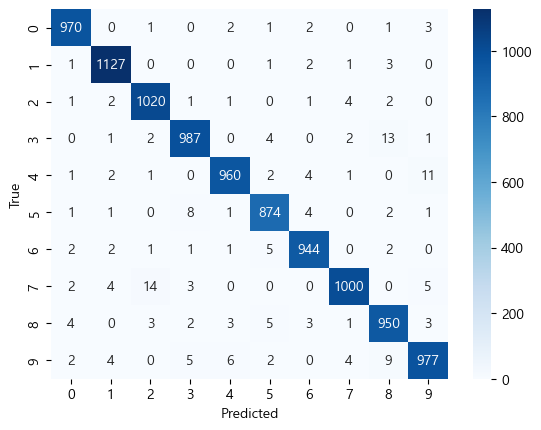

In [12]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
plt.rc('font', family='Malgun gothic')

cm = confusion_matrix(y_test, np.argmax(y_pred, axis=1))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()